<a href="https://colab.research.google.com/github/AKookani/Qiskit_course/blob/Main/Qiskit2_new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Quantum Coding Course** (summer 2024)

**Instructors:**
Ali Kookani, Yousef Mafi

\

*Atlas Stem*

# Section 3: Quantum circuit running on QPU

*   Prerequisites
*   Sampler
*   Result retrieval
*   Estimator

## Prerequisites to connect to IBMQ

In [1]:
# Install the main Qiskit library, which includes the core components for building and running quantum circuits.
!pip install qiskit ipywidgets

# Install the 'pylatexenc' package, which is required to render LaTeX formatted output
# (such as circuit diagrams) in Jupyter notebooks when using Qiskit.
!pip install pylatexenc

# Install the Qiskit Aer package, which provides high-performance simulators for running quantum circuits.
# This includes various simulation methods such as statevector, density matrix, and more.
!pip install qiskit-aer

# Install the Qiskit IBM Runtime package, which allows users to run quantum circuits on real quantum hardware
# and simulators via IBM's cloud-based quantum services.
!pip install qiskit-ibm-runtime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 40.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=79d09b7771e662a67869cddffc58ee46bd104297e2103f52a81273c2d87a60ad
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
with open('token.txt', 'r') as file:
    my_token = file.read().strip()

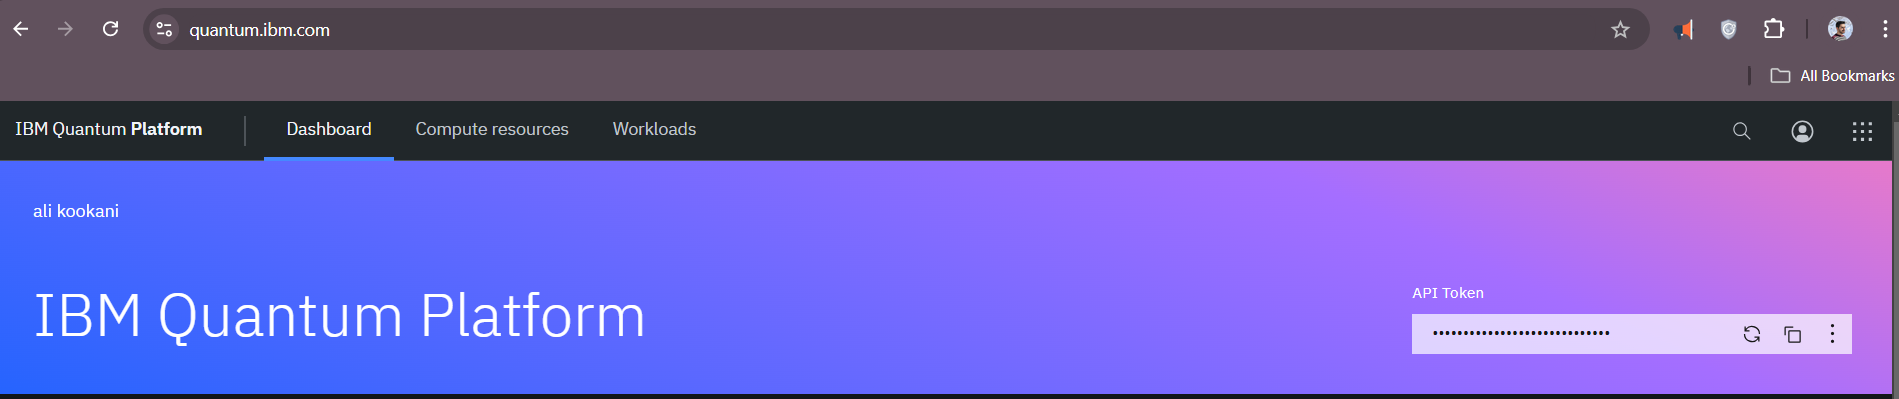

In [8]:
# Import the QiskitRuntimeService from the Qiskit IBM Runtime package.
# This service is used to interact with IBM's cloud-based quantum devices and services.
from qiskit_ibm_runtime import QiskitRuntimeService

# Initialize the Qiskit Runtime service by connecting to IBM Quantum services.
# Specify the communication channel as "ibm_quantum" to access IBM's cloud-based quantum computers.
# Use the provided `my_token` to authenticate and gain access to your IBM Quantum account.
QiskitRuntimeService.save_account(
    token="Pi3u-o2rS6aqUzCFW8GoVofiQYKDg7Ctznpu4VEI_Csg", # Use the 44-character API_KEY you created and saved from the IBM Quantum Platform Home dashboard
    overwrite=True
#    instance="<CRN>" # Optional
)
service = QiskitRuntimeService()
# Alternatively, you can initialize the service by explicitly passing a token as a string (e.g., "your_token").
# Uncomment the line below and replace "your_token" with your actual IBM Quantum API token.
# service = QiskitRuntimeService(channel="ibm_quantum", token="your_token")

qiskit_runtime_service.__init__:WARNING:2026-05-26 13:37:57,772: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: Ali. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


In [9]:
# Import mathematical constants and functions, specifically `pi` from the math library.
# `pi` will be used for angle-based operations in quantum circuits.
from math import pi

# Import necessary components from Qiskit:
# `QuantumCircuit` is used to define quantum circuits.
# `QuantumRegister` and `ClassicalRegister` are used to create quantum and classical registers for the circuit.
# `transpile` is used to optimize or translate a quantum circuit for a specific backend.
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile

# Import `Parameter` from Qiskit circuit library to create parameterized quantum circuits.
# Parameters are used to make circuits more flexible by allowing variables in place of fixed values.
from qiskit.circuit import Parameter

# Import `SparsePauliOp` from Qiskit quantum information library.
# It represents Pauli operators (like X, Y, Z) with coefficients in a sparse format, useful in observables.
from qiskit.quantum_info import SparsePauliOp

# Import `plot_distribution` from Qiskit visualization tools.
# It helps visualize the probability distribution of quantum measurement outcomes.
from qiskit.visualization import plot_distribution

# Import `AerSimulator` from Qiskit Aer.
# This is a high-performance simulator for running quantum circuits on classical hardware.
from qiskit_aer import AerSimulator

# Import `SamplerV2` and `EstimatorV2` from Qiskit IBM Runtime.
# These classes are used to run sampling and estimation tasks on IBM Quantum's backends.
from qiskit_ibm_runtime import SamplerV2, EstimatorV2

In [11]:
# Create an instance of the AerSimulator backend, which simulates quantum circuits on classical hardware.
# The simulator is seeded with `42` to ensure the results are reproducible for this simulation run.
# The simulator can also be configured to simulate noise, making it behave more like a real quantum computer.
backend_aer = AerSimulator()  # We can add noise here for noisy simulations

# Retrieve an IBM Quantum backend using the `QiskitRuntimeService`.
# Here, we're accessing the 'ibm_kyiv' backend, a real quantum device available through the IBM Quantum service.
# This enables running quantum circuits on actual quantum hardware.
backend_ibm = service.backend('ibm_marrakesh')

qiskit_runtime_service.backends:WARNING:2026-05-26 13:41:14,965: Using instance: Ali, plan: open


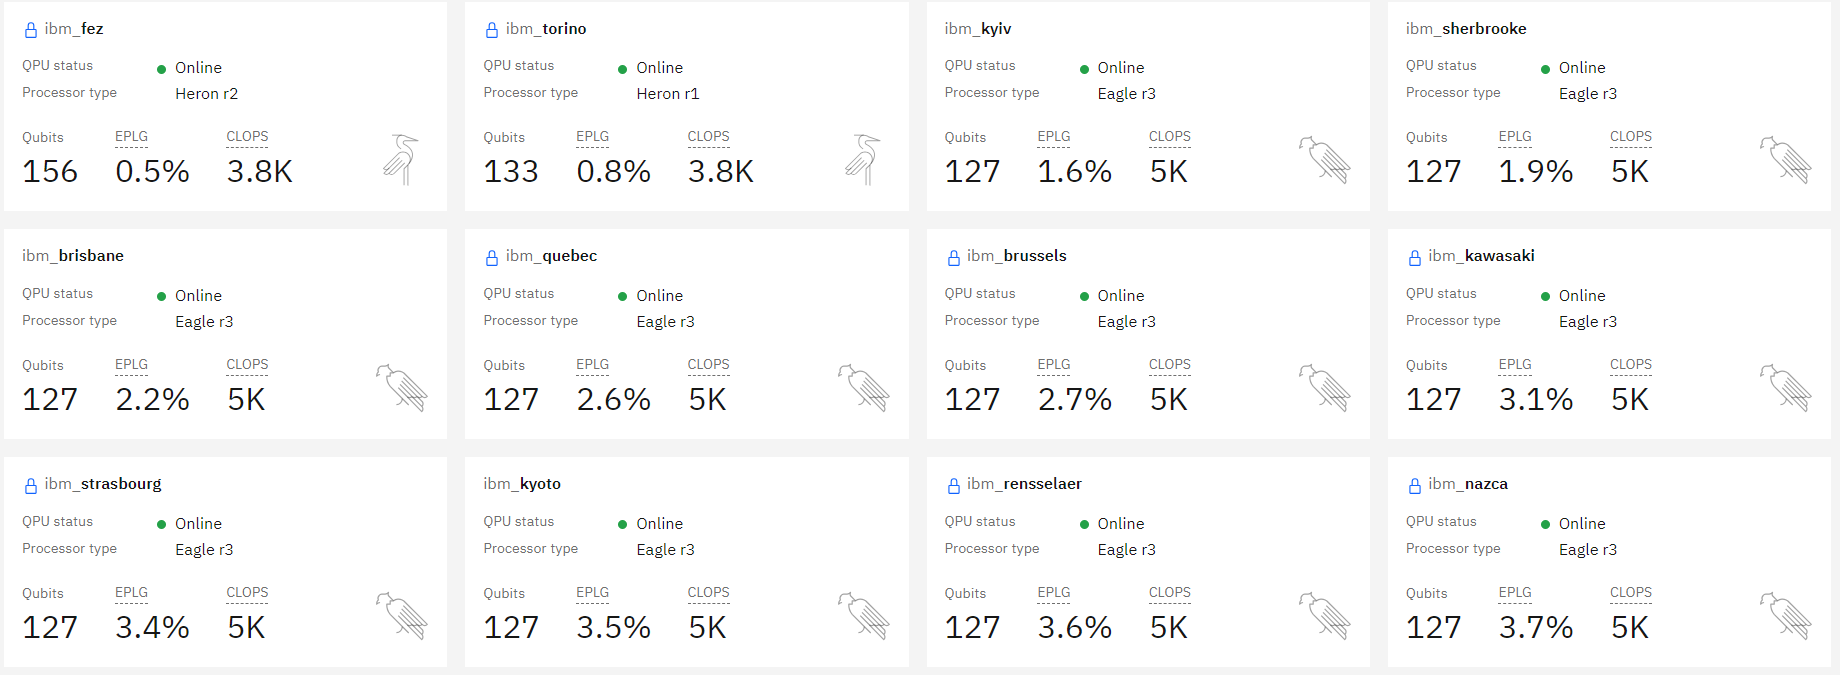

## Aer vs IBMQ Sampler

### Backend

In [12]:
# Create an instance of `SamplerV2` for the AerSimulator backend.
# This sampler will run quantum circuits on the AerSimulator, which simulates the circuit execution classically.
sampler_aer = SamplerV2(mode=backend_aer)

# Create another instance of `SamplerV2` for the IBM Quantum backend ('ibm_kyiv').
# This sampler will run quantum circuits on the actual quantum hardware, providing real quantum sampling.
sampler_ibm = SamplerV2(mode=backend_aer)

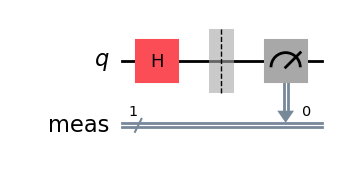

In [13]:
# Create a quantum circuit with 1 qubit.
qc = QuantumCircuit(1)

# Apply a Hadamard gate (H) to the qubit at index 0.
# The Hadamard gate creates superposition, putting the qubit in an equal superposition of |0⟩ and |1⟩.
qc.h(0)

# Add measurement operations to measure the state of the qubit.
# `measure_all()` measures all qubits in the circuit, collapsing their states into classical bits.
qc.measure_all()

# Draw the quantum circuit in 'mpl' (Matplotlib) format for visualization.
qc.draw('mpl')

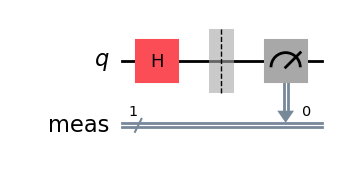

In [14]:
# Transpile the quantum circuit for the AerSimulator backend.
qc1_aer = transpile(qc, backend=backend_aer)

# Visualize the transpiled circuit.
qc1_aer.draw('mpl')

### Transpilation

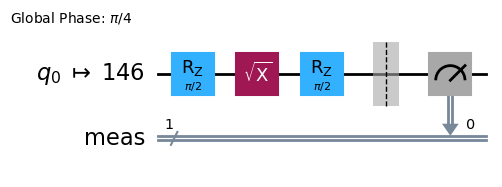

In [15]:
# Transpile the quantum circuit for the IBM backend.
qc1_ibm = transpile(qc, backend=backend_ibm)

# Draw the transpiled circuit, hiding idle wires.
qc1_ibm.draw('mpl', idle_wires=False)

In [16]:
from qiskit.quantum_info import Statevector

# Function to visualize the circuit and its Bloch sphere representation.
def visualization(Quantum_Circuit):
    # Display the quantum circuit.
    display(Quantum_Circuit.draw('mpl'))

    # Get the statevector from the quantum circuit and display the Bloch sphere.
    state = Statevector.from_instruction(Quantum_Circuit)
    display(state.draw('bloch'))

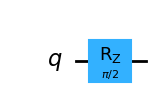

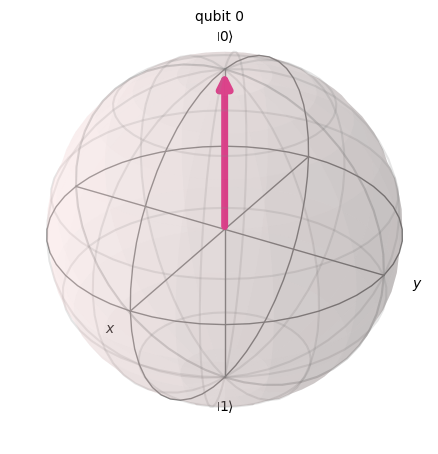

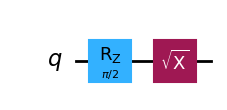

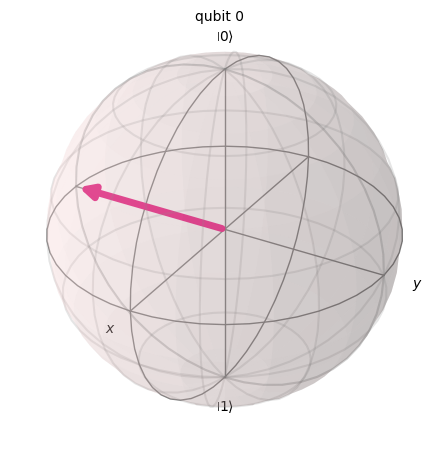

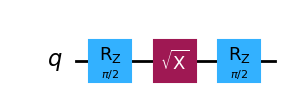

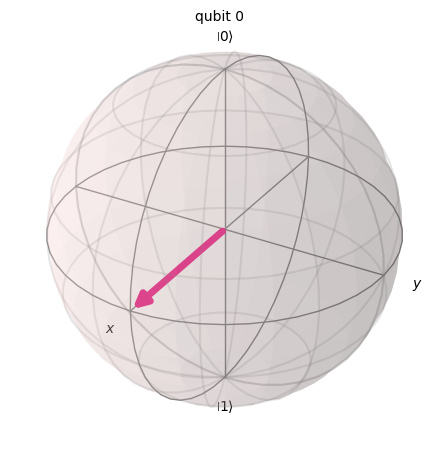

In [17]:
# Create a quantum circuit with 1 qubit.
qc = QuantumCircuit(1)

# Apply an RZ rotation of π/2 to the qubit.
qc.rz(pi/2, 0)
visualization(qc)  # Visualize the circuit and its state.

# Apply an SX (square-root of X) gate to the qubit.
qc.sx(0)
visualization(qc)  # Visualize the updated circuit and state.

# Apply another RZ rotation of π/2 to the qubit.
qc.rz(pi/2, 0)
visualization(qc)  # Final visualization.

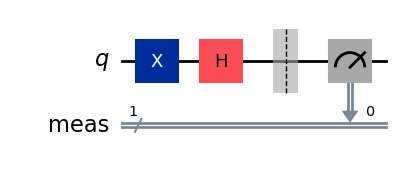

In [18]:
# Create a quantum circuit with 1 qubit.
test = QuantumCircuit(1)

# Apply an X gate (Pauli-X) to flip the qubit.
test.x(0)

# Apply a Hadamard gate to the qubit.
test.h(0)

# Measure the qubit.
test.measure_all()

# Draw the quantum circuit.
test.draw('mpl')

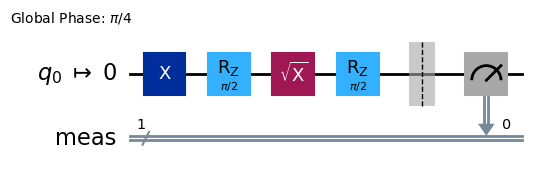

In [19]:
# Transpile the test circuit for the IBM backend with no optimization.
test_transpiled = transpile(test, backend=backend_ibm, optimization_level=0)

# Draw the transpiled circuit, hiding idle wires.
test_transpiled.draw('mpl', idle_wires=False)

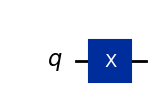

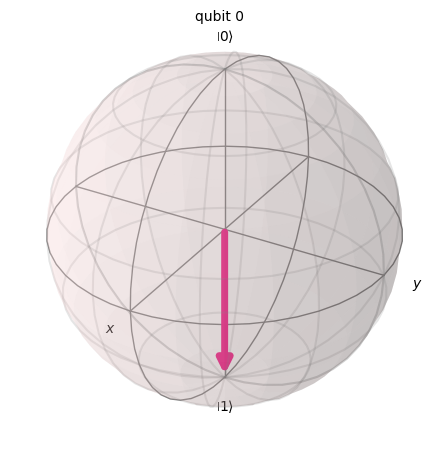

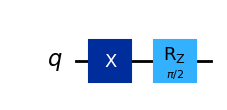

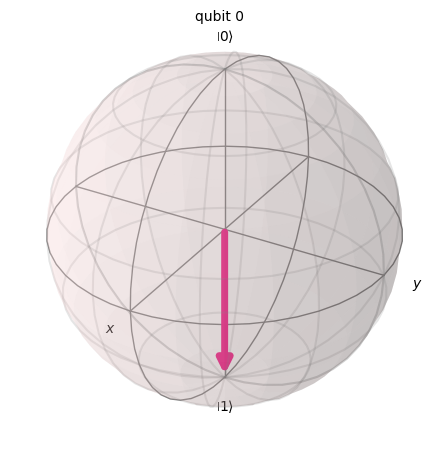

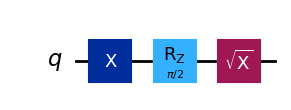

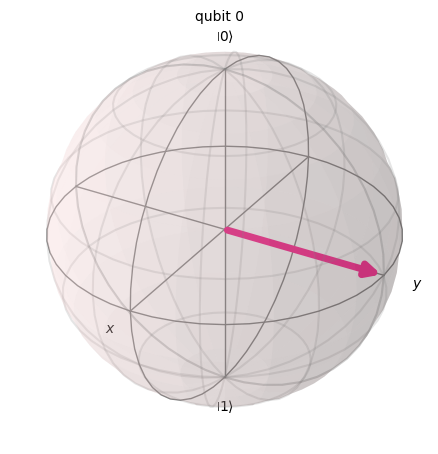

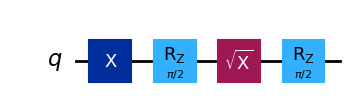

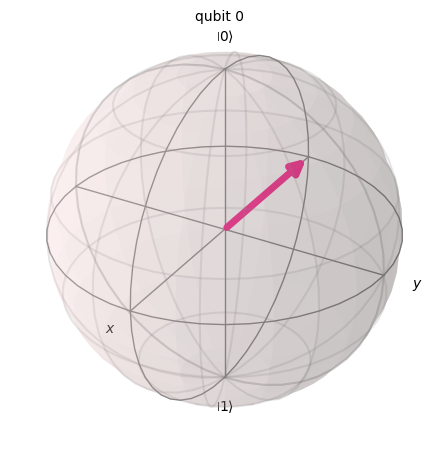

In [20]:
# Create a quantum circuit with 1 qubit.
test = QuantumCircuit(1)

# Apply an X gate (Pauli-X) to flip the qubit.
test.x(0)
visualization(test)  # Visualize the circuit and its state.

# Apply an RZ rotation of π/2 to the qubit.
test.rz(pi/2, 0)
visualization(test)  # Visualize the updated circuit and state.

# Apply an SX (square-root of X) gate to the qubit.
test.sx(0)
visualization(test)  # Visualize the updated circuit and state.

# Apply another RZ rotation of π/2 to the qubit.
test.rz(pi/2, 0)
visualization(test)  # Final visualization.

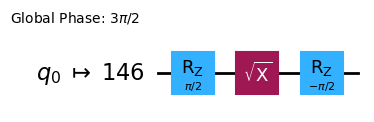

In [21]:
# Transpile the 'test' circuit for the IBM backend with default optimization.
test_transpiled = transpile(test, backend=backend_ibm)

# Draw the transpiled circuit, hiding idle wires.
test_transpiled.draw('mpl', idle_wires=False)

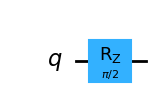

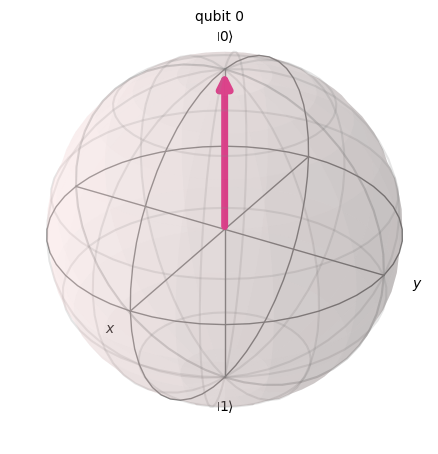

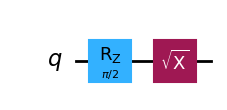

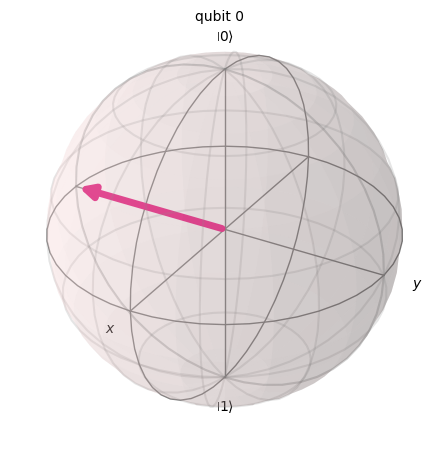

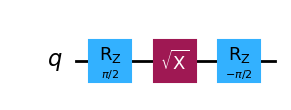

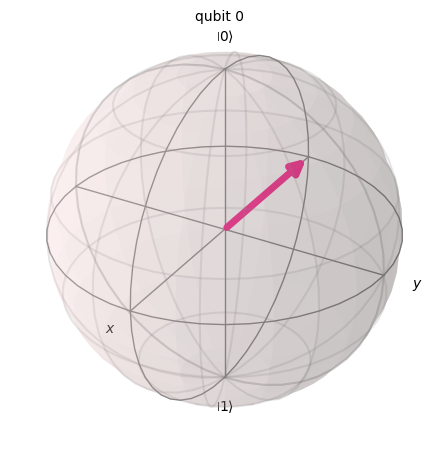

In [22]:
# Create a quantum circuit with 1 qubit.
test = QuantumCircuit(1)

# Apply an RZ rotation of π/2 to the qubit.
test.rz(pi/2, 0)
visualization(test)  # Visualize the circuit and its state.

# Apply an SX (square-root of X) gate to the qubit.
test.sx(0)
visualization(test)  # Visualize the updated circuit and state.

# Apply an RZ rotation of -π/2 to the qubit.
test.rz(-pi/2, 0)
visualization(test)  # Final visualization.

### PUB(Primitive Unified Blocs) preparation

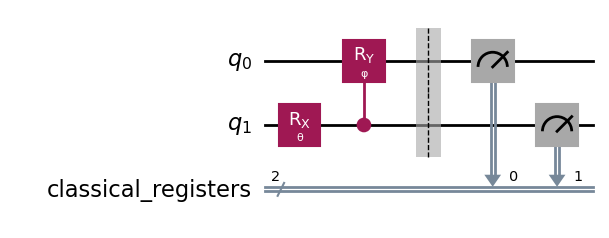

In [23]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit import Parameter

# Define parameters for the quantum circuit.
theta = Parameter('θ')
phi = Parameter('φ')

# Create quantum and classical registers.
qr = QuantumRegister(2, name='q')
cr = ClassicalRegister(2, name='classical_registers')

# Initialize a quantum circuit with the registers.
qc2 = QuantumCircuit(qr, cr)

# Apply an RX rotation with parameter theta to qubit 1.
qc2.rx(theta, 1)

# Apply a CRY gate with parameter phi between qubits 1 and 0.
qc2.cry(phi, 1, 0)

# Add a barrier to separate the gates from the measurements.
qc2.barrier()

# Measure the quantum bits into the classical bits.
qc2.measure(qr, cr)

# Draw the quantum circuit.
qc2.draw('mpl')

In [24]:
# Display the parameters used in the quantum circuit.
print(qc2.parameters)

ParameterView([Parameter(θ), Parameter(φ)])


angels = $
[[\theta_0, \phi_0], [\theta_1, \phi_1], [\theta_2, \phi_2], …]
$

In [25]:
# Define a list of angles, each as a pair [theta, phi].
angles = [[pi/4, pi/2], [pi/3, pi], [pi/2, 2*pi]]

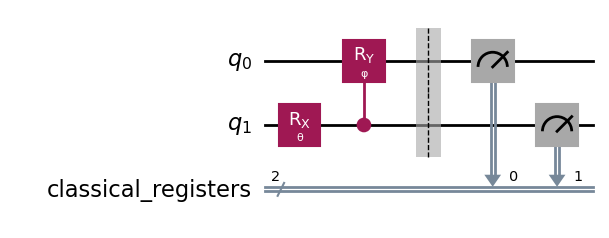

In [26]:
# Transpile the quantum circuit for the Aer backend.
qc2_aer = transpile(qc2, backend=backend_aer)

# Draw the transpiled circuit.
qc2_aer.draw('mpl')

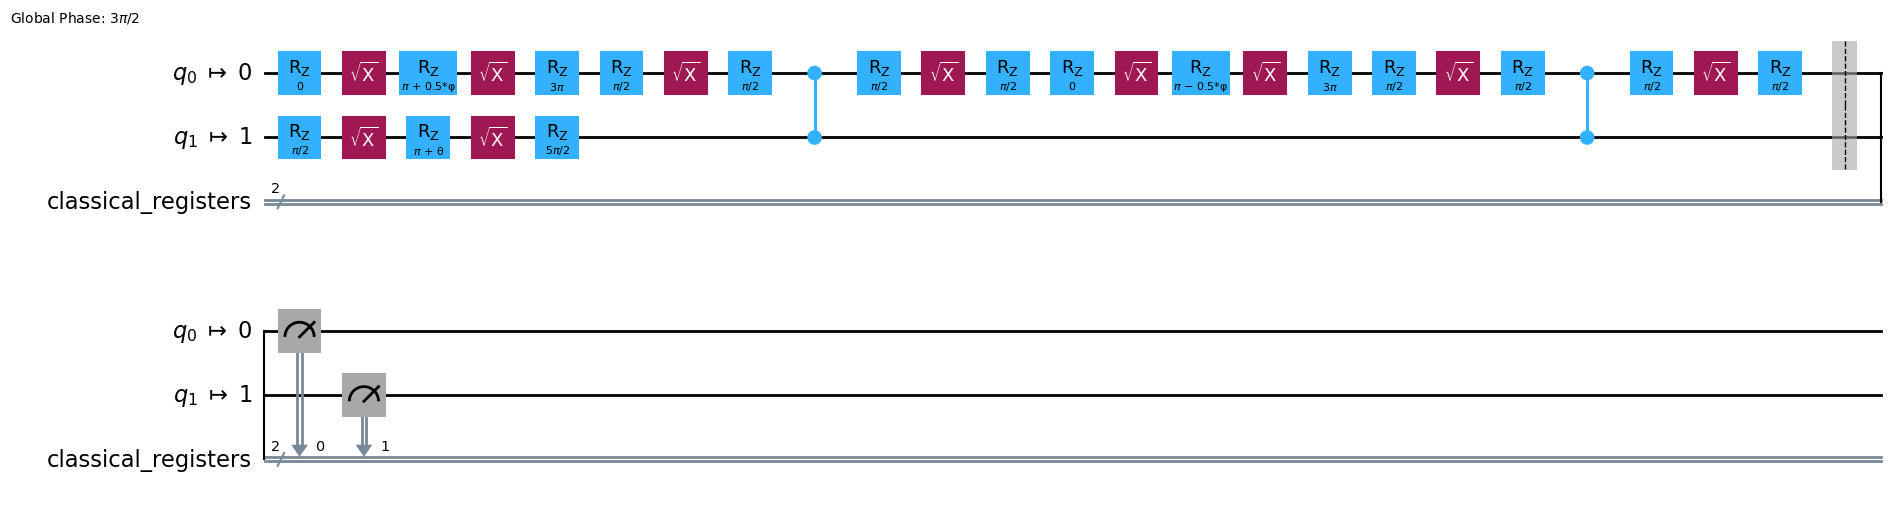

In [27]:
# Transpile the quantum circuit for the IBM backend with no optimization.
qc2_ibm = transpile(qc2, backend=backend_ibm, optimization_level=0)

# Draw the transpiled circuit, hiding idle wires.
qc2_ibm.draw('mpl', idle_wires=False)

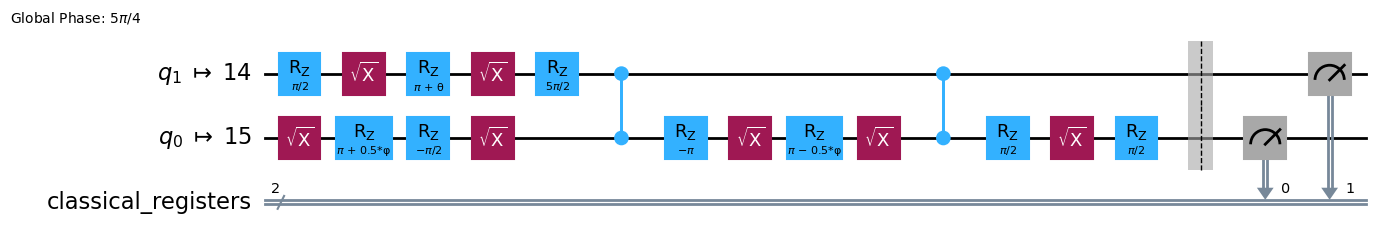

In [28]:
# Transpile the quantum circuit for the IBM backend with default optimization.
qc2_ibm = transpile(qc2, backend=backend_ibm)

# Draw the transpiled circuit, hiding idle wires.
qc2_ibm.draw('mpl', idle_wires=False)

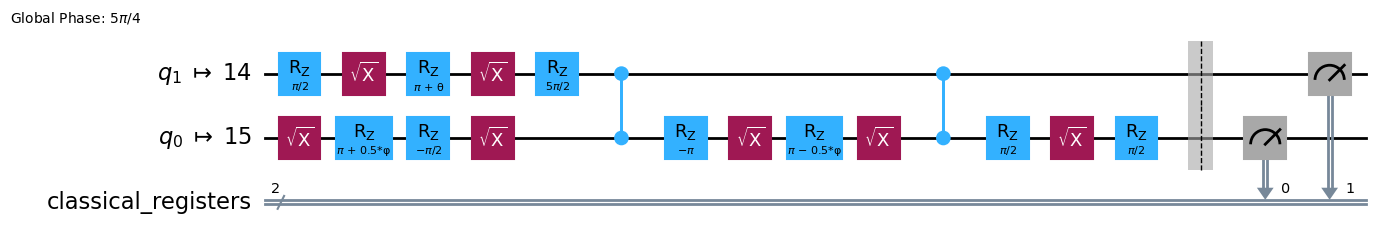

In [29]:
# Transpile the quantum circuit for the IBM backend with maximum optimization level (3).
qc2_ibm = transpile(qc2, backend=backend_ibm, optimization_level=3)

# Draw the transpiled circuit, hiding idle wires.
qc2_ibm.draw('mpl', idle_wires=False)

optimization_level (Optional[int])

How much optimization to perform on the circuits. Higher levels generate more optimized circuits, at the expense of longer transpilation time.

* 0: no optimization
* 1: light optimization
* 2: heavy optimization
* 3: even heavier optimization

If None, level 1 will be chosen as default.

### QPU's results

In [30]:
# Run the sampler on the Aer backend with specific shots for each circuit.
job_aer = sampler_aer.run([(qc1_aer, None, 100), (qc2_aer, angles, 1000)])

# Run the sampler on the IBM backend with specific shots for each circuit.
job_ibm = sampler_ibm.run([(qc1_ibm, None, 100), (qc2_ibm, angles, 1000)])

In [31]:
# Retrieve the results from the Aer backend job.
result_aer = job_aer.result()

# Retrieve the results from the IBM backend job.
result_ibm = job_ibm.result()

In [32]:
# Extract the measurement counts for the first circuit (qc1_aer) from the Aer backend results.
counts_qc1_aer = result_aer[0].data.meas.get_counts()

# Extract the measurement counts for the first circuit (qc1_ibm) from the IBM backend results.
counts_qc1_ibm = result_ibm[0].data.meas.get_counts()

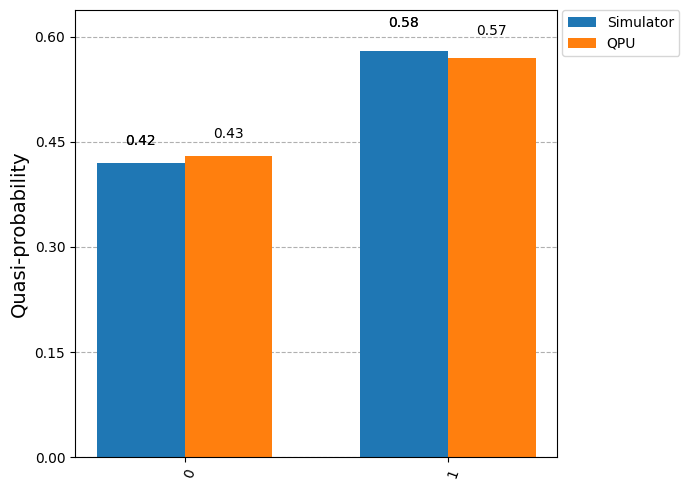

In [33]:
# Plot the distribution of measurement counts for both the Aer simulator and the IBM QPU results.
plot_distribution([counts_qc1_aer, counts_qc1_ibm], legend=['Simulator', 'QPU'])

In [34]:
# Extract the measurement counts for the second circuit (qc2_aer) from the Aer backend results.
counts_qc2_aer = result_aer[1].data.classical_registers.get_counts()

# Extract the measurement counts for the second circuit (qc2_ibm) from the IBM backend results.
counts_qc2_ibm = result_ibm[1].data.classical_registers.get_counts()

In [35]:
# Print the measurement counts for the second circuit from both the Aer simulator and the IBM QPU.
print(f'Aer: {counts_qc2_aer}')
print(f'IBM: {counts_qc2_ibm}')

Aer: {'00': 2100, '11': 320, '10': 580}
IBM: {'00': 2055, '11': 374, '10': 571}


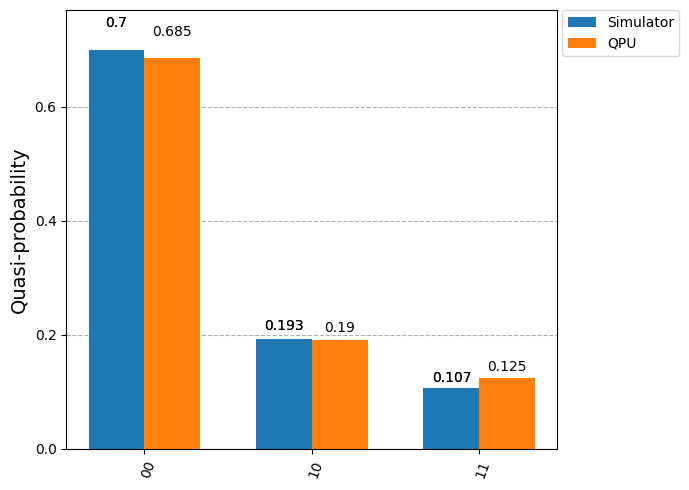

In [36]:
# Plot the distribution of measurement counts for the second circuit from both the Aer simulator and the IBM QPU.
plot_distribution([counts_qc2_aer, counts_qc2_ibm], legend=['Simulator', 'QPU'])

Aer: {'00': 856, '11': 75, '10': 69}
IBM: {'00': 829, '11': 94, '10': 77}


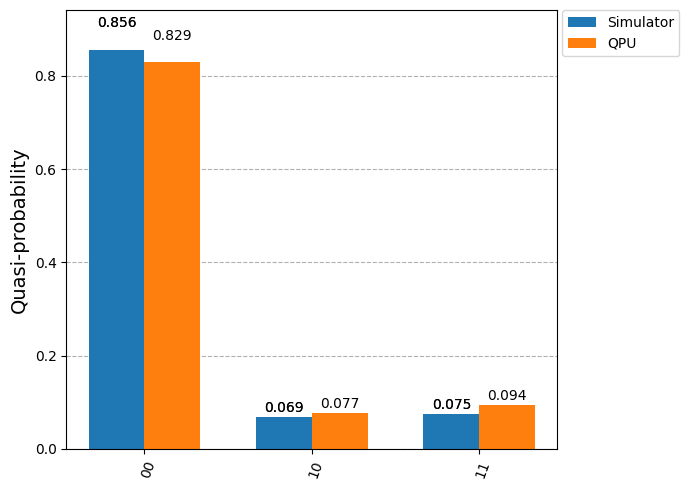

Aer: {'00': 755, '11': 245}
IBM: {'11': 280, '00': 720}


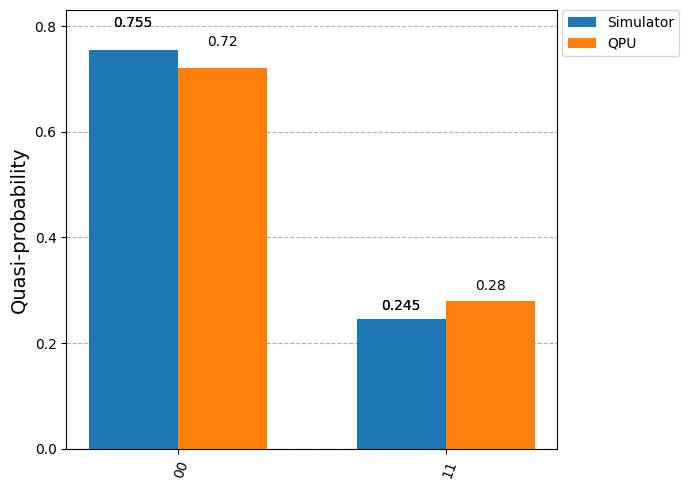

Aer: {'00': 489, '10': 511}
IBM: {'00': 506, '10': 494}


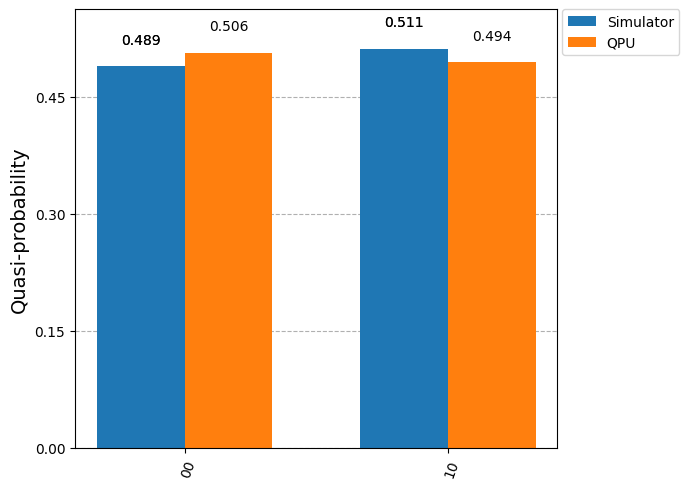

In [37]:
# Iterate over each angle in the angles list and print and plot the measurement counts for each.
for i in range(len(angles)):
    # Get measurement counts for the i-th angle from both Aer and IBM results.
    counts_qc2_aer = result_aer[1].data.classical_registers.get_counts(i)
    counts_qc2_ibm = result_ibm[1].data.classical_registers.get_counts(i)

    # Print the counts from the Aer simulator and IBM QPU for the current angle.
    print(f'Aer: {counts_qc2_aer}')
    print(f'IBM: {counts_qc2_ibm}')

    # Display the plot of measurement counts for the current angle.
    display(plot_distribution([counts_qc2_aer, counts_qc2_ibm], legend=['Simulator', 'QPU']))

## Retrive results

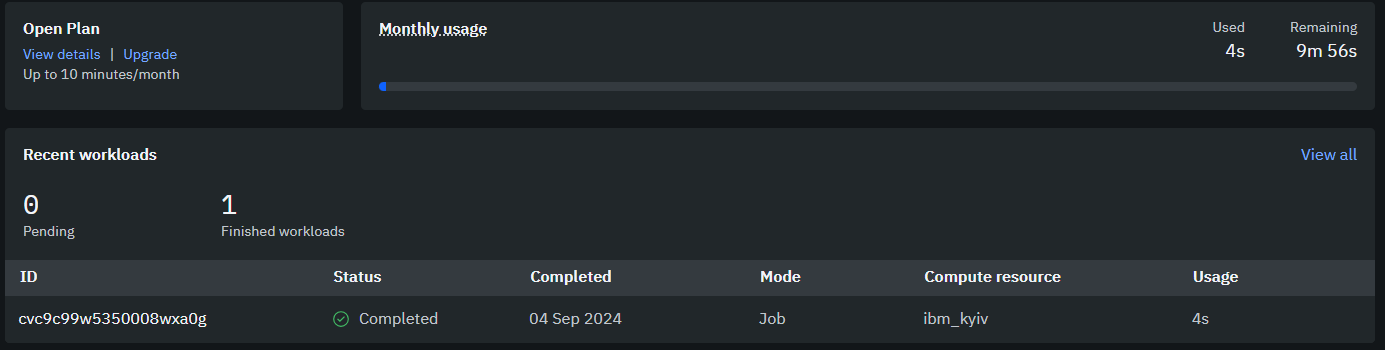

In [ ]:
# Save the IBM Quantum account credentials for future use.
service.save_account(my_token, channel="ibm_quantum")

In [ ]:
# Retrieve a previously saved job using its job ID.
job_saved = QiskitRuntimeService().job('cvm7wa1z17rg008drc9g')

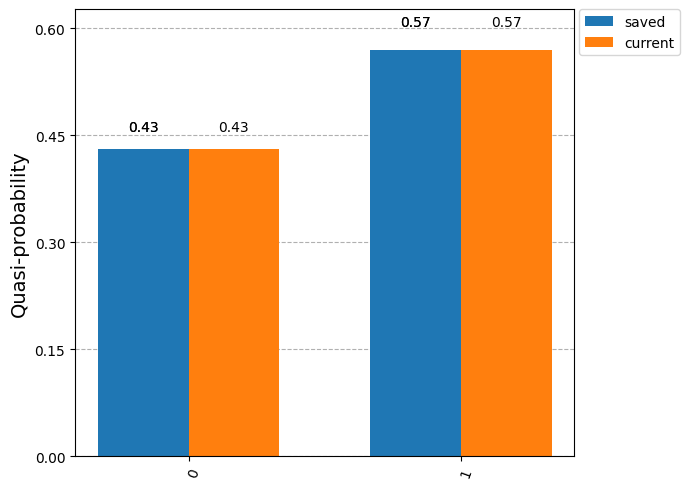

saved: {'00': 2055, '11': 374, '10': 571}
current: {'00': 2055, '11': 374, '10': 571}
Aggregate


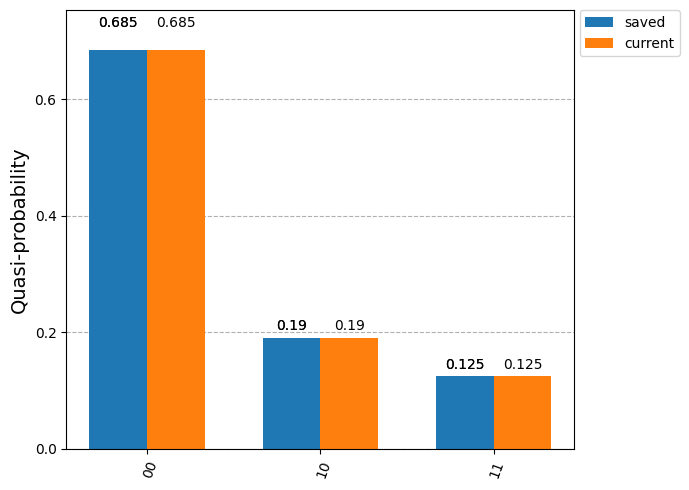

saved: {'00': 829, '11': 94, '10': 77}
current: {'00': 829, '11': 94, '10': 77}


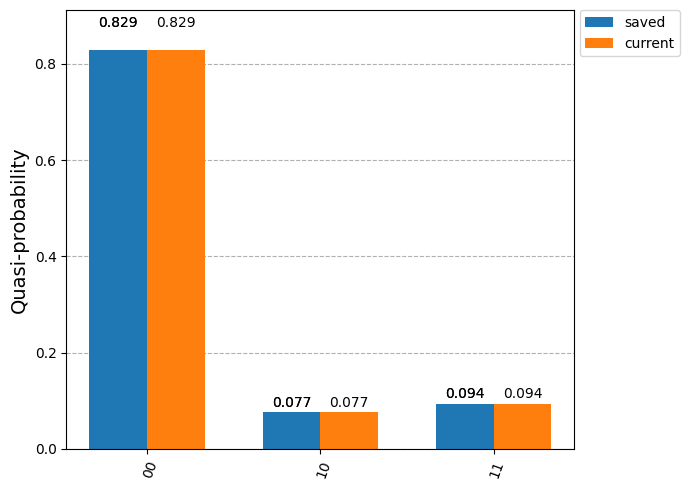

saved: {'11': 280, '00': 720}
current: {'11': 280, '00': 720}


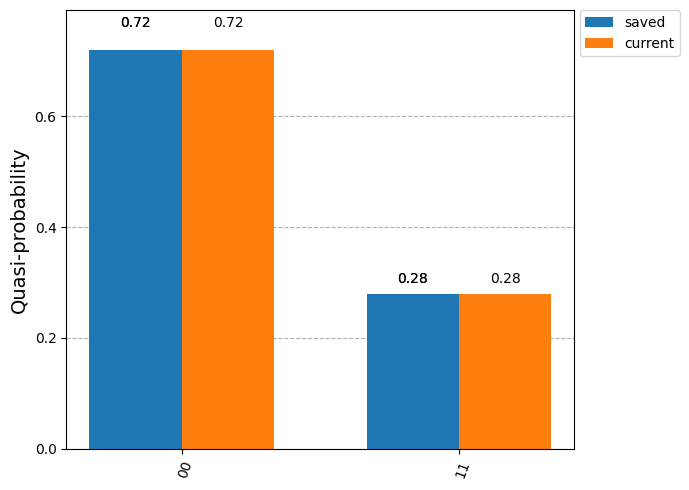

saved: {'00': 506, '10': 494}
current: {'00': 506, '10': 494}


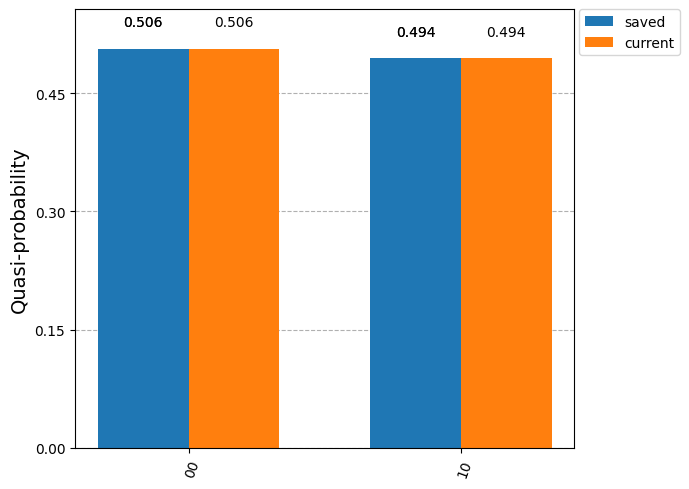

In [38]:
# Retrieve the result of the previously saved job.
saved_result = job_ibm.result()

# Extract and plot the measurement counts for the first circuit from the saved result and the current IBM result.
saved_counts_qc1 = saved_result[0].data.meas.get_counts()
display(plot_distribution([saved_counts_qc1, counts_qc1_ibm], legend=['saved', 'current']))

# Extract and print the measurement counts for the second circuit from both the saved result and the current IBM result.
saved_counts_qc2 = saved_result[1].data.classical_registers.get_counts()
counts_qc2_ibm = result_ibm[1].data.classical_registers.get_counts()
print(f'saved: {saved_counts_qc2}')
print(f'current: {counts_qc2_ibm}')

# Plot the aggregated measurement counts for the second circuit.
print("Aggregate")
display(plot_distribution([saved_counts_qc2, counts_qc2_ibm], legend=['saved', 'current']))

# Iterate over each angle, comparing saved and current counts for each angle.
for i in range(len(angles)):
    counts_qc2_saved = saved_result[1].data.classical_registers.get_counts(i)
    counts_qc2_ibm = result_ibm[1].data.classical_registers.get_counts(i)
    print(f'saved: {counts_qc2_saved}')
    print(f'current: {counts_qc2_ibm}')
    display(plot_distribution([counts_qc2_saved, counts_qc2_ibm], legend=['saved', 'current']))

## Estimator

In [39]:
# Initialize EstimatorV2 for the Aer simulator backend.
estimator_aer = EstimatorV2(mode=backend_aer)

# Initialize EstimatorV2 for the IBM Quantum backend.
estimator_ibm = EstimatorV2(mode=backend_ibm)

In [40]:
# Define a list of observables for a two-qubit system.
# Each observable is represented by SparsePauliOps with specific Pauli operators and coefficients.
obsv_list = [[SparsePauliOp(["XX", "IY"], [0.5, 0.5])],
             [SparsePauliOp(["XX"], [1])],
             [SparsePauliOp(["IY"], [1])]]

**Map observables to backend layout**

In [41]:
# Obtain the layout of the quantum circuit for IBM backend.
layout = qc2_ibm.layout

# Prepare observables for the IBM backend by applying the layout to each observable.
# This ensures the observables match the qubit mapping of the backend.
obsv_ibm = []
for obsv in obsv_list:
#  print(obsv[0], obsv)
  obsv_temp = obsv[0].apply_layout(layout)  # Apply the layout to the observable
  print(obsv_temp)  # Print the adjusted observable
  obsv_ibm.append([obsv_temp])  # Append the adjusted observable to the list

SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIXXIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIYIIIIIIIIIIIIIII'],
              coeffs=[0.5+0.j, 0.5+0.j])
SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIXXIIIIIIIIIIIIII'],
              coeffs=[1.+0.j])
SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIYIIIIIIIIIIIIIII'],
              coeffs=[1.+0.j])


In [42]:
layout

TranspileLayout(initial_layout=Layout({
15: <Qubit register=(2, "q"), index=0>,
14: <Qubit register=(2, "q"), index=1>,
0: <Qubit register=(154, "ancilla"), index=0>,
1: <Qubit register=(154, "ancilla"), index=1>,
2: <Qubit register=(154, "ancilla"), index=2>,
3: <Qubit register=(154, "ancilla"), index=3>,
4: <Qubit register=(154, "ancilla"), index=4>,
5: <Qubit register=(154, "ancilla"), index=5>,
6: <Qubit register=(154, "ancilla"), index=6>,
7: <Qubit register=(154, "ancilla"), index=7>,
8: <Qubit register=(154, "ancilla"), index=8>,
9: <Qubit register=(154, "ancilla"), index=9>,
10: <Qubit register=(154, "ancilla"), index=10>,
11: <Qubit register=(154, "ancilla"), index=11>,
12: <Qubit register=(154, "ancilla"), index=12>,
13: <Qubit register=(154, "ancilla"), index=13>,
16: <Qubit register=(154, "ancilla"), index=14>,
17: <Qubit register=(154, "ancilla"), index=15>,
18: <Qubit register=(154, "ancilla"), index=16>,
19: <Qubit register=(154, "ancilla"), index=17>,
20: <Qubit registe

In [43]:
# Run the estimator on the Aer backend with the quantum circuit, list of observables, angles, and a noise parameter.
# No need to map observables for Aer as it's a simulator.
job2_aer = estimator_aer.run([(qc2_aer, obsv_list, angles, 0.01)])

# Run the estimator on the IBM backend with the quantum circuit, mapped observables, angles, and a noise parameter.
job2_ibm = estimator_ibm.run([(qc2_ibm, obsv_ibm, angles, 0.01)])

In [44]:
# Extract expectation values from the results of the estimators
exp_vals_aer = job2_aer.result()[0].data.evs  # Expectation values from Aer
exp_vals_ibm = job2_ibm.result()[0].data.evs  # Expectation values from IBM

# Print the expectation values for comparison
print(f"Expectation values of Aer: \n{exp_vals_aer}")
print(f"Expectation values of IBM: \n{exp_vals_ibm}")

Expectation values of Aer: 
[[-0.0075 -0.0141 -0.0043]
 [-0.0152 -0.0154 -0.007 ]
 [ 0.0002 -0.0128 -0.0016]]
Expectation values of IBM: 
[[ 0.00062571 -0.02731942  0.00119025]
 [-0.02262715 -0.0388547  -0.00571393]
 [ 0.02387856 -0.01578413  0.00809443]]


3 lists because of 3 observables

each lists 3 expectation value because of 3 angels

## Session

There are 3 ways to execute in `Runtime`

1. **Job:** (Simple execution)
2. **Session:** (Hybrid CPU and QPU execution)
3. **Batch:** (Parallel execution)

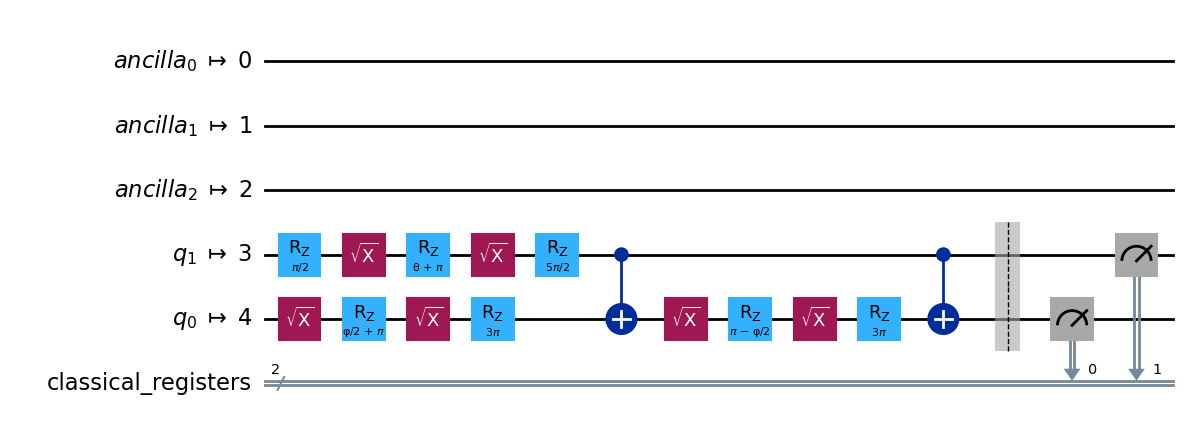

In [ ]:
from qiskit_ibm_runtime import Session
from qiskit_ibm_runtime.fake_provider import FakeManilaV2

fake_backend = FakeManilaV2()
FakeSim_qc2 = transpile(qc2, backend=fake_backend)
FakeSim_qc2.draw('mpl')

In [ ]:
FakeSim_obsv = [[obsv[0].apply_layout(FakeSim_qc2.layout)] for obsv in obsv_list]
print(FakeSim_obsv)

[[SparsePauliOp(['XXIII', 'YIIII'],
              coeffs=[0.5+0.j, 0.5+0.j])], [SparsePauliOp(['XXIII'],
              coeffs=[1.+0.j])], [SparsePauliOp(['YIIII'],
              coeffs=[1.+0.j])]]


In [ ]:
# Context manager
with Session(# service = QiskitRunTimeService(),
    backend=fake_backend) as session:
    estimator = EstimatorV2(mode=session)
    results = estimator.run([(FakeSim_qc2, FakeSim_obsv, angles, 0.01)]).result()[0]
    print(f"Expection values: \n {results.data.evs}")

Expection values: 
 [[ 0.0047  0.0114  0.0177]
 [-0.0032  0.012   0.0114]
 [ 0.0126  0.0108  0.024 ]]
